In [1]:
import sys
print(sys.executable)

import torch, astropy, lenstronomy, zoobot
print(torch.__version__, torch.cuda.is_available())
print(astropy.__version__)

/home/yawpa/miniconda3/envs/lensengine/bin/python
2.11.0+cu128 True
8.0.1


In [3]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.mast import Observations

coords = SkyCoord("09h46m08.32s", "+10d06m13.6s", frame="icrs")
print(coords.ra.deg, coords.dec.deg)

obs_table = Observations.query_criteria(
    coordinates=coords,
    radius="10 arcsec",
    obs_collection="HST",
    instrument_name="ACS/WFC"
)
print(len(obs_table))
obs_table[:5]

146.53466666666665 10.103777777777777
0


intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max,objID1,distance
str1,str1,str1,str1,str1,str1,str1,str1,str1,str1,float64,float64,str1,str1,int64,float64,float64,float64,str1,float64,float64,str1,float64,str1,str1,int64,str1,str1,str1,str1,bool,float64,str1,str1,float64,float64,str1,float64


In [4]:
obs_table = Observations.query_criteria(
    coordinates=coords,
    radius="10 arcsec",
    obs_collection="HST"
)
print(len(obs_table))
obs_table[["instrument_name", "filters", "t_exptime", "obs_id"]]

0


instrument_name,filters,t_exptime,obs_id
str1,str1,float64,str1


In [5]:
obs_table = Observations.query_object("SLACS SDSS J0946+1006", radius="10 arcsec")
print(len(obs_table))

85


In [7]:
hst_obs = obs_table[obs_table["obs_collection"] == "HST"]
print(len(hst_obs))
print(set(hst_obs["instrument_name"]))

21
{np.str_('WFC3/IR'), np.str_('WFC3/UVIS'), np.str_('ACS/WFC'), np.str_('WFPC2/PC')}


In [8]:
acs_obs = hst_obs[hst_obs["instrument_name"] == "ACS/WFC"]
print(len(acs_obs))
acs_obs[["filters", "t_exptime", "obs_id", "calib_level"]]

5


filters,t_exptime,obs_id,calib_level
str17,float64,str51,int64
F814W,2096.0,hst_10886_14_acs_wfc_f814w_j9op14,3
detection,2096.0,hst_10886_14_acs_wfc_total_j9op14,3
F814W,2096.0,hst_skycell-p1537x06y11_acs_wfc_f814w_all,3
F814W,2096.0,j9op14010,3
F814W,2096.0,hst_skycell-p1537x06y12_acs_wfc_f814w_all,3


In [9]:
target_obs = acs_obs[acs_obs["obs_id"] == "hst_10886_14_acs_wfc_f814w_j9op14"]
products = Observations.get_product_list(target_obs)
print(len(products))
products[["productType", "productSubGroupDescription", "size", "productFilename"]]

81


productType,productSubGroupDescription,size,productFilename
str9,str11,int64,str50
AUXILIARY,FLT_HLET,112320,j9op14ohq_flt_hlet.fits
AUXILIARY,SPT,57600,j9op14ohq_spt.fits
AUXILIARY,TRL,69120,j9op14ohq_trl.fits
INFO,LOG,16090,j9op14ohq_log.txt
PREVIEW,--,1612252,j9op14ohq_raw.jpg
PREVIEW,--,1657765,j9op14ohq_flc.jpg
PREVIEW,--,1661304,j9op14ohq_flt.jpg
SCIENCE,FLC,168448320,j9op14ohq_flc.fits
SCIENCE,FLT,168442560,j9op14ohq_flt.fits


In [10]:
from astroquery.mast import Observations

download_result = Observations.download_products(
    products,
    productFilename="hst_10886_14_acs_wfc_f814w_j9op14_drc.fits",
    download_dir="../data/raw"
)
download_result

Local Path,Status,Message,URL
str105,str8,object,object
../data/raw/mastDownload/HST/hst_10886_14_acs_wfc_f814w_j9op14/hst_10886_14_acs_wfc_f814w_j9op14_drc.fits,COMPLETE,None,None


In [11]:
import os
path = "../data/raw/mastDownload/HST/hst_10886_14_acs_wfc_f814w_j9op14/hst_10886_14_acs_wfc_f814w_j9op14_drc.fits"
print(os.path.getsize(path) / 1e6, "MB")

from astropy.io import fits
with fits.open(path) as hdul:
    hdul.info()

345.4416 MB
Filename: ../data/raw/mastDownload/HST/hst_10886_14_acs_wfc_f814w_j9op14/hst_10886_14_acs_wfc_f814w_j9op14_drc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     906   ()      
  1  SCI           1 ImageHDU        90   (5371, 5357)   float32   
  2  WHT           1 ImageHDU        45   (5371, 5357)   float32   
  3  CTX           1 ImageHDU        38   (5371, 5357)   int32   
  4  HDRTAB        1 BinTableHDU    638   8R x 314C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, 4A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 23A, D, D, D, D, K, K, K, 8A, K, 23A, 9A, 20A, K, 4A, K, K, K, K, K, K, 23A, D, D, D, D, K, K, 3A, 3A, 4A, 4A, L, D, D, D, 3A, 1A, K, D, D, D, 24A, 3A, 4A, 4A, 12A, 12A, 23A, 8A, 23A, 10A, 10A, D, D, 3A, 3A, 23A, 4A, 8A, 7A, 23A, D, K, D, 6A, 9A, 8A, D, D, L, 4A, 44A, 3A, K, 7A, 5A, 3A, D, 13A, 8A, 4A, 3A, L, K, L, K, L, K, K, D, D, D, D, D, D, 3A, 1A, D, 23A, D, D, 

(5357, 5371) >f4
-0.19900633 146.44315 0.1669477


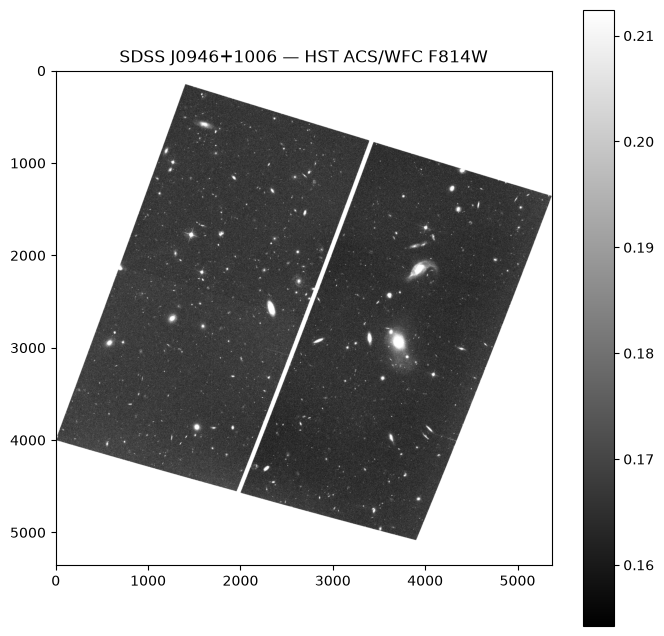

In [12]:
import numpy as np
import matplotlib.pyplot as plt

with fits.open(path) as hdul:
    sci_data = hdul["SCI"].data

print(sci_data.shape, sci_data.dtype)
print(np.nanmin(sci_data), np.nanmax(sci_data), np.nanmedian(sci_data))

plt.figure(figsize=(8, 8))
plt.imshow(sci_data, cmap="gray", vmin=np.nanpercentile(sci_data, 5), vmax=np.nanpercentile(sci_data, 99.5))
plt.colorbar()
plt.title("SDSS J0946+1006 — HST ACS/WFC F814W")
plt.show()

In [13]:
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

target_coord = SkyCoord.from_name("SLACS SDSS J0946+1006")
print(target_coord.ra.deg, target_coord.dec.deg)

with fits.open(path) as hdul:
    wcs = WCS(hdul["SCI"].header)
    sci_data = hdul["SCI"].data

x_pix, y_pix = wcs.world_to_pixel(target_coord)
print(x_pix, y_pix)

146.73617048 10.1146953
3712.5937763575275 2941.5242998709073


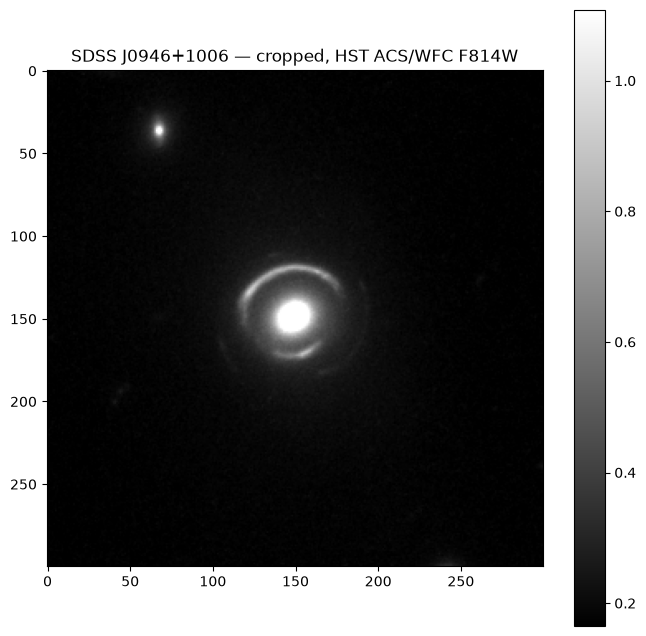

In [16]:
crop_size = 150
x_int, y_int = int(np.round(x_pix)), int(np.round(y_pix))

cutout = sci_data[y_int - crop_size:y_int + crop_size, x_int - crop_size:x_int + crop_size]

plt.figure(figsize=(8, 8))
plt.imshow(cutout, cmap="gray", vmin=np.nanpercentile(cutout, 10), vmax=np.nanpercentile(cutout, 99.7))
plt.colorbar()
plt.title("SDSS J0946+1006 — cropped, HST ACS/WFC F814W")
plt.show()